<a href="https://colab.research.google.com/github/williamG7/Barcelona-Electricity-Consumption-Analysis/blob/main/Barcelona_Electricity_Consumption_Analysis_GuzmanWilliam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis de Sostenibilidad Energética en Barcelona
El objetivo del **reto final del módulo profesional** es **aplicar los conocimientos adquiridos** para **mejorar la sociedad y el medio ambiente** a partir de **datos** extraídos de ámbitos **reales**.

Como **expertos/as en Machine Learning**, existe una **responsabilidad hacia la sociedad**, ya que **la información es poder** y el dominio de la gestión de datos conlleva la obligación moral de **aportar a la sociedad** para **contribuir a la construcción de un mundo mejor** para las generaciones futuras.

De hecho, ya hace algunos años que existe el término de [*migrante climático*](https://www.termcat.cat/ca/diccionaris-en-linia/295/fitxa/NDMzMTY2Mg%3D%3D), que hace referencia al fenómeno por el cual una persona abandona su país no a causa de guerra, hambre o falta de trabajo, sino debido a las condiciones climatológicas alteradas por el cambio climático.

Asimismo, desde hace tiempo se habla de una nueva corriente denominada [*religión del datismo*](https://blog.caixabank.es/blogcaixabank/ca/dadisme-aixi-es-la-nova-religio-de-les-dades/#), o *la religión de los datos*, en la que los datos otorgan sentido a todo y existe una confianza plena en ellos. Un ejemplo representativo es el de los inversores en bolsa: actualmente no son los brokers quienes determinan dónde invertir siguiendo su criterio, sino algoritmos que calculan millones de probabilidades por segundo de forma automática.

En el marco del Talent Arena, se presentó recientemente un caso en el que dos robots calculaban inversiones el uno contra el otro, provocando que las decisiones de uno afectaran directamente a los precios del otro, generando así una dinámica completamente automatizada.

> **Si los algoritmos toman las decisiones más importantes de la humanidad de manera automática, ¿cuál es el papel de los seres humanos?**

Desde la perspectiva de expertos/as en gestión de datos formados en un centro educativo de excelencia, se considera necesario realizar un **retorno a la sociedad** como reconocimiento por la oportunidad de haber accedido a una educación de calidad.

Por lo tanto, el presente reto se abordará con rigor, con el objetivo de **generar un informe que pueda ser presentado ante las autoridades competentes de la administración pública, como el Ayuntamiento de Barcelona**.

![Open Data BCN y ODS 2030](https://opendata-ajuntament.barcelona.cat/sites/default/files/field/image/ODS_OD_Cat%20%281%29.PNG)

## El reto:

Para el reto final se aplicarán las habilidades desarrolladas en la gestión de datos con el fin de realizar un retorno a la sociedad, proponiendo ideas de mejora sostenibles del entorno local.

El desarrollo del proyecto seguirá los objetivos de la Agenda 2030 para el Desarrollo Sostenible: https://opendata-ajuntament.barcelona.cat/ca/novetat-ODS

## Requerimientos:

- Exponer ideas de mejora iniciales e hipótesis a demostrar
- EDA (Exploratory Data Analysis) y tratamiento de los datos
- Uso de regresiones para determinar el futuro del reto elegido
- Uso de árboles de decisión para descubrir qué variables son más determinantes
- Uso de algoritmos de clasificación para etiquetar los datos en grupos
- Gráficos aportados para ilustrar las hipótesis
- Creatividad, uso de APIs, webscraping, uso de datos geoespaciales
- Reflexión razonada sobre los resultados y propuesta de mejora
- Maquetación profesional del informe

---

## Reto seleccionado:
El conjunto de datos seleccionado para el desarrollo del proyecto es el análisis del consumo eléctrico en Barcelona por código postal, sector económico y franja horaria, enmarcado en los objetivos **ODS 7: Energía asequible y no contaminante** y **ODS 11: Ciudades y comunidades sostenibles**.

Fuente de datos: https://opendata-ajuntament.barcelona.cat/data/ca/dataset/consum-electricitat-bcn

## Hipótesis a demostrar:
En este apartado, realizaremos una reflexión sobre qué conclusiones podemos extraer de los datos estudiados. Qué propuestas podemos hacer, qué ideas de mejora del medio ambiente y gestión de recursos, etc.
1. El consumo eléctrico varía de forma significativa según el código postal.
2. Existen diferencias claras de consumo según el sector económico.
3. La franja horaria influye directamente en el consumo eléctrico.
4. Se pueden construir modelos que ayuden a predecir o clasificar niveles de consumo eléctrico.
5. El análisis de estos patrones puede servir para proponer medidas de mejora en eficiencia energética.

---

## Imports necesarios

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import json
import io

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from google.colab import files

## Descargar los datasets

In [ ]:
print("Cargar CSVs de electricidad")
uploaded = files.upload()

lista_df = []

for nombre, contenido in uploaded.items():
    digitos = ''.join(filter(str.isdigit, nombre))
    año = int(digitos[:4])

    df_temp = pd.read_csv(io.BytesIO(contenido))
    df_temp['Año'] = año
    lista_df.append(df_temp)
    print(f"Cargado: {nombre} ({len(df_temp)} filas) — año {año}")

df = pd.concat(lista_df, ignore_index=True)
print(f"\nTotal de filas: {len(df)}")
print(df.head())

Cargar CSVs de electricidad


Saving 2020_consum_electricitat_bcn.csv to 2020_consum_electricitat_bcn.csv
Saving 2021_consum_electricitat_bcn.csv to 2021_consum_electricitat_bcn.csv
Saving 2023_consum_electricitat_bcn.csv to 2023_consum_electricitat_bcn.csv
Saving 2024_consum_electricitat_BCN.csv to 2024_consum_electricitat_BCN.csv
Saving 2019_consum_electricitat_bcn.csv to 2019_consum_electricitat_bcn.csv
Saving 2022_consum_electricitat_bcn.csv to 2022_consum_electricitat_bcn.csv
Saving 2025_consum_electricitat_BCN.csv to 2025_consum_electricitat_BCN.csv
Cargado: 2020_consum_electricitat_bcn.csv (245210 filas) — año 2020
Cargado: 2021_consum_electricitat_bcn.csv (243645 filas) — año 2021
Cargado: 2023_consum_electricitat_bcn.csv (241125 filas) — año 2023
Cargado: 2024_consum_electricitat_BCN.csv (229705 filas) — año 2024
Cargado: 2019_consum_electricitat_bcn.csv (245270 filas) — año 2019
Cargado: 2022_consum_electricitat_bcn.csv (251070 filas) — año 2022
Cargado: 2025_consum_electricitat_BCN.csv (209105 filas) — a

## Exploración de datos (EDA)

### Valores de los datasets

In [ ]:
print("Informacion general")
print(f"Filas: {len(df)}")
print(f"Columnas: {df.columns.tolist()}")
print(f"\nTipos de datos:\n{df.dtypes}")
print(f"\nValores nulos:\n{df.isnull().sum()}")

Informacion general
Filas: 1665130
Columnas: ['Any', 'Data', 'Codi_Postal', 'Sector_Economic', 'Tram_Horari', 'Valor', 'Año']

Tipos de datos:
Any                 int64
Data               object
Codi_Postal         int64
Sector_Economic    object
Tram_Horari        object
Valor               int64
Año                 int64
dtype: object

Valores nulos:
Any                0
Data               0
Codi_Postal        0
Sector_Economic    0
Tram_Horari        0
Valor              0
Año                0
dtype: int64


### Eliminar columna redundante

In [ ]:
df = df.drop(columns=['Año'])

### Normalizar códigos postales a formato de 5 dígitos

In [ ]:
df["Codi_Postal"] = (
    pd.to_numeric(df["Codi_Postal"], errors="coerce")
    .astype("Int64")
    .astype("string")
    .str.zfill(5)
)

print("Códigos postales normalizados:")
print(sorted(df["Codi_Postal"].dropna().unique())[:10])

Códigos postales normalizados:
['08001', '08002', '08003', '08004', '08005', '08006', '08007', '08008', '08009', '08010']


### Años disponibles

In [ ]:
print(sorted(df['Any'].unique()))

[np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]


### Valores nulos

In [ ]:
print("Valores nulos por columna:")
print(df.isnull().sum())
print(f"\nPorcentaje de nulos:")
print((df.isnull().sum() / len(df) * 100).round(2))

Valores nulos por columna:
Any                0
Data               0
Codi_Postal        0
Sector_Economic    0
Tram_Horari        0
Valor              0
dtype: int64

Porcentaje de nulos:
Any                0.0
Data               0.0
Codi_Postal        0.0
Sector_Economic    0.0
Tram_Horari        0.0
Valor              0.0
dtype: float64


### Duplicados

In [ ]:
duplicados = df.duplicated().sum()
print(f"Filas duplicadas: {duplicados}")

Filas duplicadas: 0


### Valores únicos por columna

In [ ]:
print(f"Años disponibles: {sorted(df['Any'].unique())}")
print(f"\nSectores económicos: {df['Sector_Economic'].unique()}")
print(f"\nTramos horarios: {df['Tram_Horari'].unique()}")
print(f"\nCódigos postales únicos: {df['Codi_Postal'].nunique()}")
print(f"Códigos postales: {sorted(df['Codi_Postal'].unique())}")

Años disponibles: [np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]

Sectores económicos: ['Indústria' 'Residencial' 'Serveis' 'No especificat']

Tramos horarios: ['De 00:00:00 a 05:59:59 h' 'De 06:00:00 a 11:59:59 h'
 'De 12:00:00 a 17:59:59 h' 'De 18:00:00 a 23:59:59 h' 'No consta']

Códigos postales únicos: 42
Códigos postales: ['08001', '08002', '08003', '08004', '08005', '08006', '08007', '08008', '08009', '08010', '08011', '08012', '08013', '08014', '08015', '08016', '08017', '08018', '08019', '08020', '08021', '08022', '08023', '08024', '08025', '08026', '08027', '08028', '08029', '08030', '08031', '08032', '08033', '08034', '08035', '08036', '08037', '08038', '08039', '08040', '08041', '08042']


### Estadísticas descriptivas del consumo

In [ ]:
print("Estadísticas descriptivas del consumo (MWh):")
print(df['Valor'].describe())

Estadísticas descriptivas del consumo (MWh):
count    1.665130e+06
mean     2.582936e+04
std      3.321072e+04
min      0.000000e+00
25%      3.640000e+02
50%      1.324700e+04
75%      4.148400e+04
max      1.472558e+06
Name: Valor, dtype: float64


### Consumo total por año

    Año  Consumo_Total_MWh
0  2019         6947665788
1  2020         6130748798
2  2021         6191946389
3  2022         6320521670
4  2023         5951235783
5  2024         5998510712
6  2025         5468607664


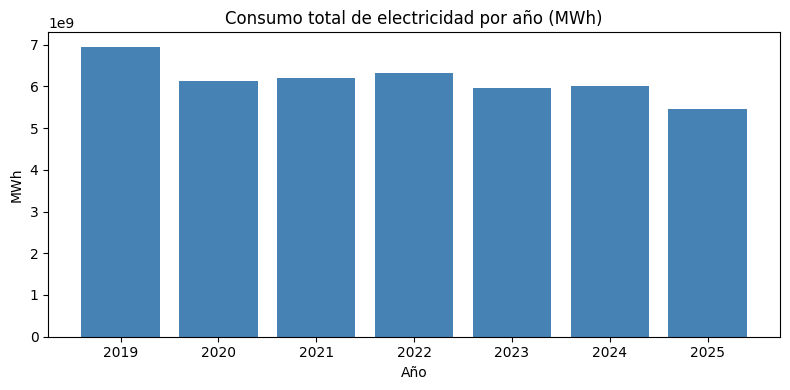

In [ ]:
consumo_año = df.groupby('Any')['Valor'].sum().reset_index()
consumo_año.columns = ['Año', 'Consumo_Total_MWh']
print(consumo_año)

plt.figure(figsize=(8, 4))
plt.bar(consumo_año['Año'], consumo_año['Consumo_Total_MWh'], color='steelblue')
plt.title('Consumo total de electricidad por año (MWh)')
plt.xlabel('Año')
plt.ylabel('MWh')
plt.tight_layout()
plt.show()

### Consumo total por sector económico

           Sector  Consumo_Total_MWh
0         Serveis        24130786622
1     Residencial        15098786593
2       Indústria         3747243414
3  No especificat           32420175


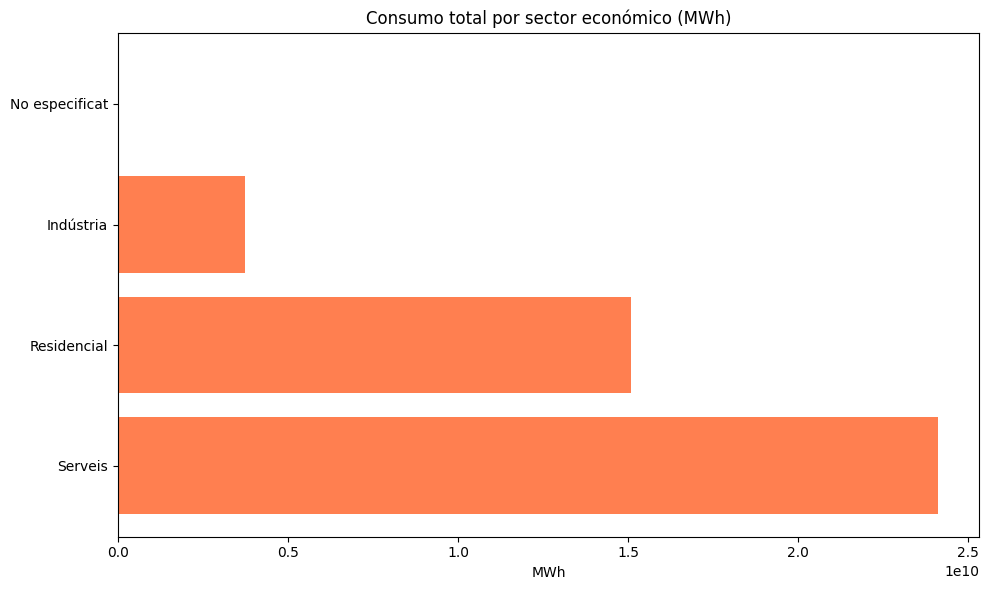

In [ ]:
consumo_sector = df.groupby('Sector_Economic')['Valor'].sum().sort_values(ascending=False).reset_index()
consumo_sector.columns = ['Sector', 'Consumo_Total_MWh']
print(consumo_sector)

plt.figure(figsize=(10, 6))
plt.barh(consumo_sector['Sector'], consumo_sector['Consumo_Total_MWh'], color='coral')
plt.title('Consumo total por sector económico (MWh)')
plt.xlabel('MWh')
plt.tight_layout()
plt.show()

### Consumo total por tramo horario

                      Tramo  Consumo_Total_MWh
0  De 12:00:00 a 17:59:59 h        12770973595
1  De 18:00:00 a 23:59:59 h        11597625145
2  De 06:00:00 a 11:59:59 h        11082273575
3  De 00:00:00 a 05:59:59 h         7551925221
4                 No consta            6439268


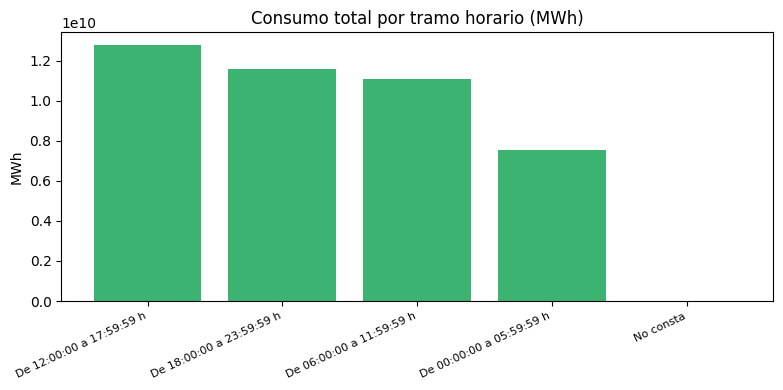

In [ ]:
consumo_tramo = df.groupby('Tram_Horari')['Valor'].sum().sort_values(ascending=False).reset_index()
consumo_tramo.columns = ['Tramo', 'Consumo_Total_MWh']
print(consumo_tramo)

plt.figure(figsize=(8, 4))
plt.bar(range(len(consumo_tramo)), consumo_tramo['Consumo_Total_MWh'], color='mediumseagreen')
plt.xticks(range(len(consumo_tramo)), consumo_tramo['Tramo'], rotation=25, ha='right', fontsize=8)
plt.title('Consumo total por tramo horario (MWh)')
plt.ylabel('MWh')
plt.tight_layout()
plt.show()

### TOP 10:

#### Códigos postales con más consumo

  Codi_Postal  Consumo_Total_MWh
0       08040         2357988092
1       08030         2151697621
2       08028         1874244605
3       08038         1626809745
4       08018         1515553812
5       08029         1406203105
6       08003         1352964056
7       08004         1352938028
8       08014         1347196966
9       08039         1338176727


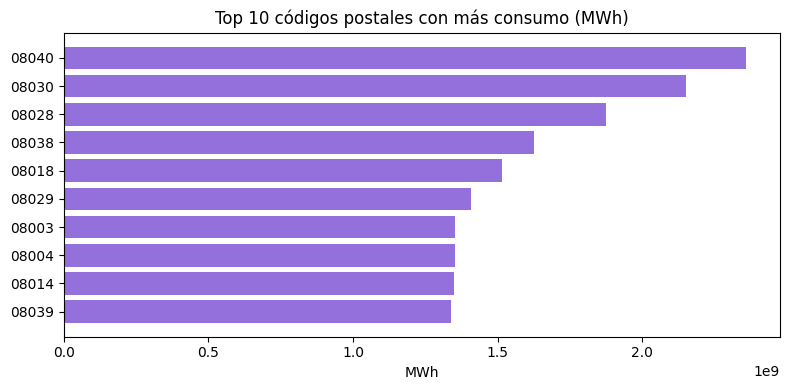

In [ ]:
# Top 10
top_cp = df.groupby('Codi_Postal')['Valor'].sum().sort_values(ascending=False).head(10).reset_index()
top_cp.columns = ['Codi_Postal', 'Consumo_Total_MWh']
print(top_cp)

plt.figure(figsize=(8, 4))
plt.barh(top_cp['Codi_Postal'].astype(str), top_cp['Consumo_Total_MWh'], color='mediumpurple')
plt.title('Top 10 códigos postales con más consumo (MWh)')
plt.xlabel('MWh')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

#### Códigos postales con menos consumo

  Codi_Postal  Consumo_Total_MWh
0       08033          299848090
1       08010          411240956
2       08008          432220524
3       08009          465925953
4       08031          482381547
5       08026          554544869
6       08032          557969414
7       08037          590394752
8       08041          592598291
9       08042          593128711


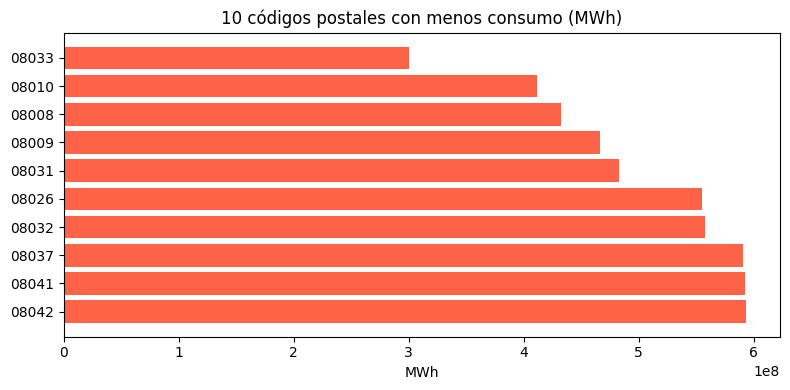

In [ ]:
# Top 10
bottom_cp = df.groupby('Codi_Postal')['Valor'].sum().sort_values(ascending=True).head(10).reset_index()
bottom_cp.columns = ['Codi_Postal', 'Consumo_Total_MWh']
print(bottom_cp)

plt.figure(figsize=(8, 4))
plt.barh(bottom_cp['Codi_Postal'].astype(str), bottom_cp['Consumo_Total_MWh'], color='tomato')
plt.title('10 códigos postales con menos consumo (MWh)')
plt.xlabel('MWh')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### Evolución del consumo por sector económico y año

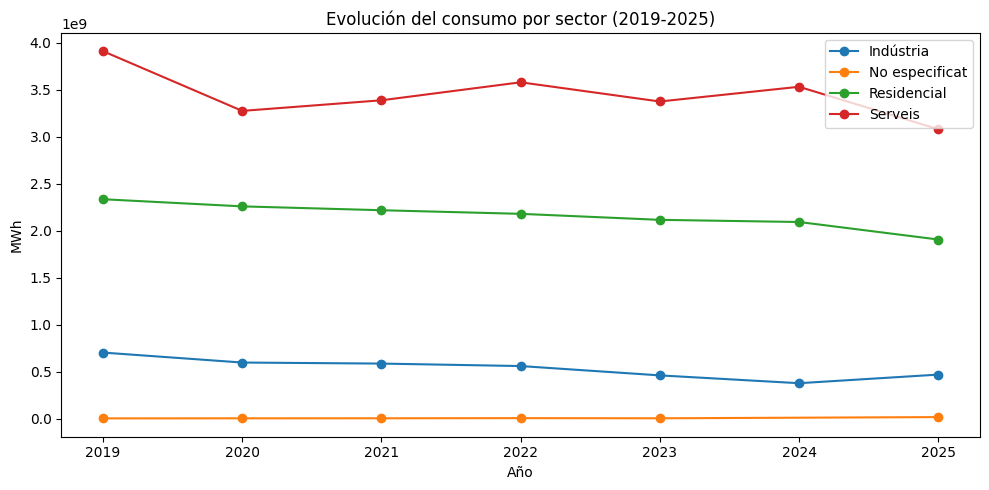

Sector    Indústria  No especificat   Residencial       Serveis
Año                                                            
2019    702395528.0       2417226.0  2.333863e+09  3.908990e+09
2020    596291939.0       2822285.0  2.257925e+09  3.273710e+09
2021    585319585.0       3140421.0  2.216840e+09  3.386647e+09
2022    559022662.0       4926660.0  2.178486e+09  3.578087e+09
2023    459707201.0       3157778.0  2.114626e+09  3.373744e+09
2024    376480387.0             NaN  2.091652e+09  3.530378e+09
2025    468026112.0      15955805.0  1.905396e+09  3.079230e+09


In [ ]:
consumo_sector_año = df.groupby(['Any', 'Sector_Economic'])['Valor'].sum().reset_index()
consumo_sector_año.columns = ['Año', 'Sector', 'Consumo_MWh']

plt.figure(figsize=(10, 5))
for sector in consumo_sector_año['Sector'].unique():
    datos = consumo_sector_año[consumo_sector_año['Sector'] == sector]
    plt.plot(datos['Año'], datos['Consumo_MWh'], marker='o', label=sector)

plt.title('Evolución del consumo por sector (2019-2025)')
plt.xlabel('Año')
plt.ylabel('MWh')
plt.legend()
plt.tight_layout()
plt.show()

print(consumo_sector_año.pivot(index='Año', columns='Sector', values='Consumo_MWh'))

### Heatmap de consumo por código postal y año

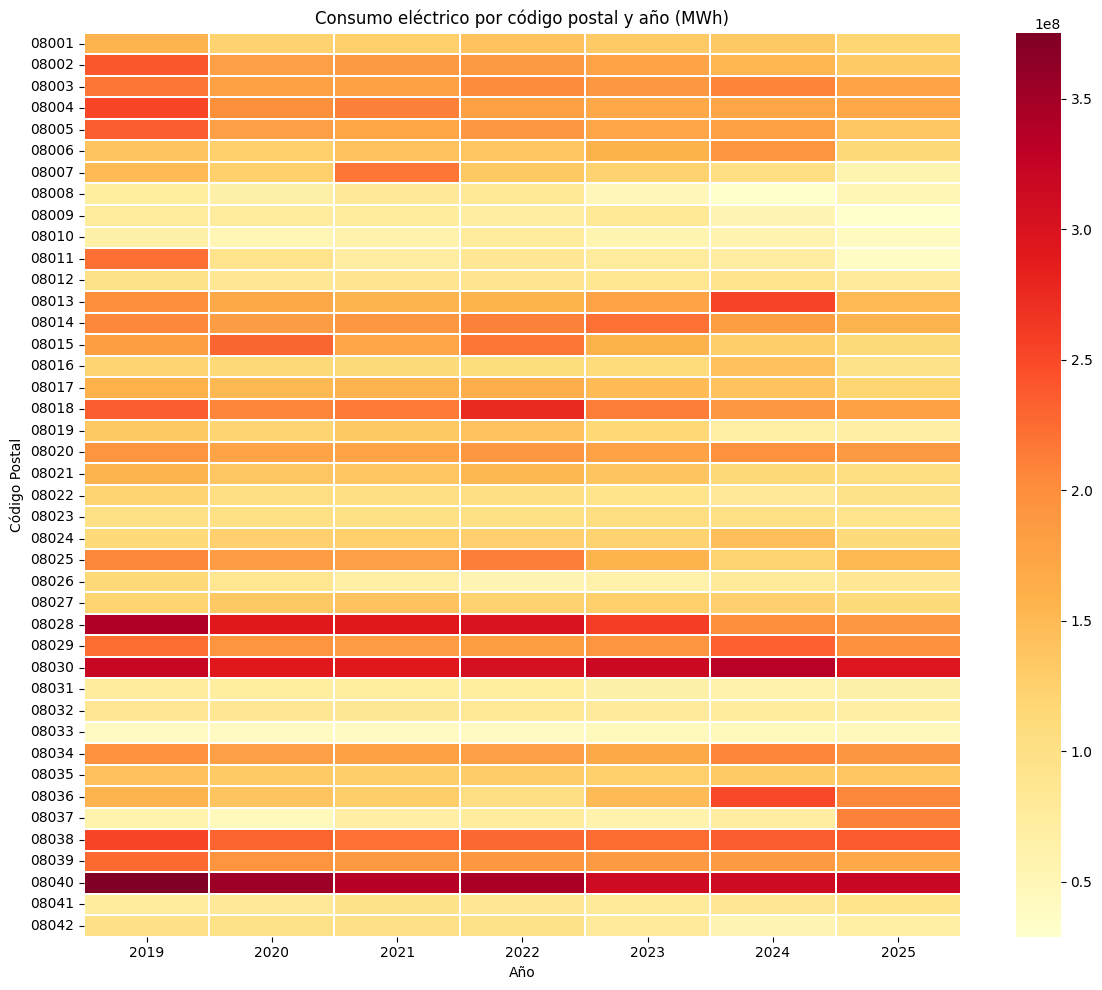

In [ ]:
heatmap_data = df.groupby(['Codi_Postal', 'Any'])['Valor'].sum().unstack()

plt.figure(figsize=(12, 10))
sns.heatmap(heatmap_data, cmap='YlOrRd', fmt='.0f', linewidths=0.3)
plt.title('Consumo eléctrico por código postal y año (MWh)')
plt.xlabel('Año')
plt.ylabel('Código Postal')
plt.tight_layout()
plt.show()

### Distribución del consumo por sector económico

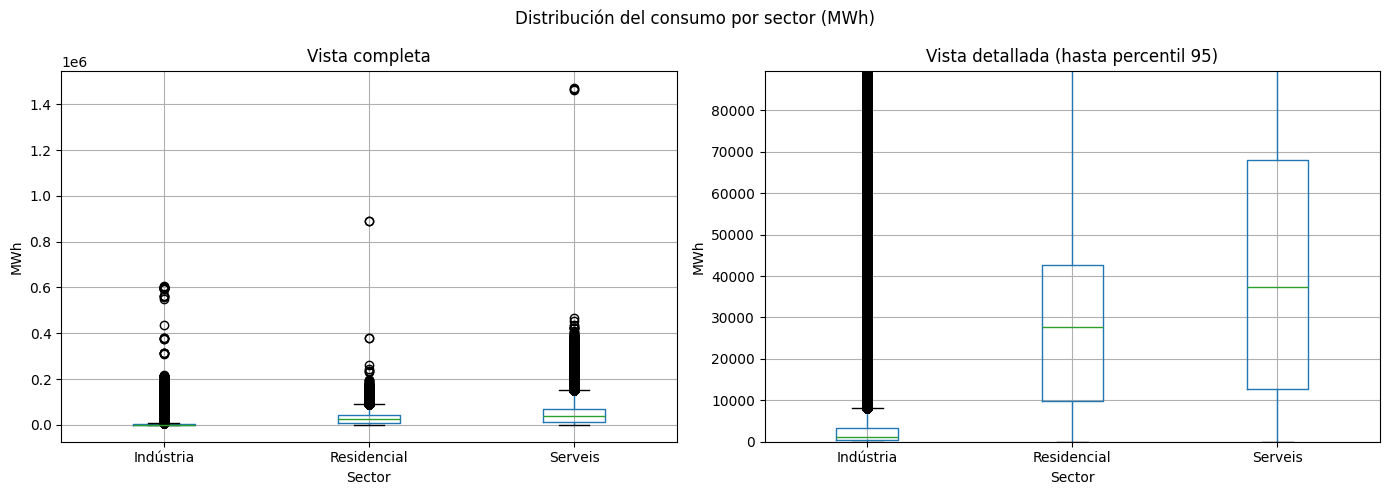

In [ ]:
# sin outliers extremos para mejor visualización
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# boxplot sin límite (vista completa)
df[df['Sector_Economic'] != 'No especificat'].boxplot(
    column='Valor',
    by='Sector_Economic',
    ax=axes[0]
)
axes[0].set_title('Vista completa')
axes[0].set_xlabel('Sector')
axes[0].set_ylabel('MWh')

# boxplot con límite en percentil 95 (vista detallada)
limite = df['Valor'].quantile(0.95)
df[df['Sector_Economic'] != 'No especificat'].boxplot(
    column='Valor',
    by='Sector_Economic',
    ax=axes[1]
)
axes[1].set_ylim(0, limite)
axes[1].set_title('Vista detallada (hasta percentil 95)')
axes[1].set_xlabel('Sector')
axes[1].set_ylabel('MWh')

fig.suptitle('Distribución del consumo por sector (MWh)')
plt.tight_layout()
plt.show()

### Tratamiento de datos

In [ ]:
# Trabajamos sobre una copia mejor para no modificar el df original usado en el EDA
df_clean = df.copy()

print(f"Filas iniciales: {len(df_clean)}")

# Eliminar filas con consumo 0
df_clean = df_clean[df_clean["Valor"] > 0]
print(f"Filas tras eliminar Valor = 0: {len(df_clean)}")

# Eliminar sector no especificado
df_clean = df_clean[df_clean["Sector_Economic"] != "No especificat"]
print(f"Filas tras eliminar 'No especificat': {len(df_clean)}")

# Eliminar tramo horario desconocido
df_clean = df_clean[df_clean["Tram_Horari"] != "No consta"]
print(f"Filas tras eliminar 'No consta': {len(df_clean)}")

# Comprobar nulos restantes
print("\nNulos restantes:")
print(df_clean.isnull().sum())

# Crear variable categórica para clasificación
q1 = df_clean["Valor"].quantile(0.33)
q2 = df_clean["Valor"].quantile(0.66)

def clasificar_consumo(x):
    if x <= q1:
        return "bajo"
    elif x <= q2:
        return "medio"
    else:
        return "alto"

df_clean["consumo_nivel"] = df_clean["Valor"].apply(clasificar_consumo)

print("\nDistribución de niveles de consumo:")
print(df_clean["consumo_nivel"].value_counts())

print(f"\nResultado final del dataset tratado: {df_clean.shape}")
display(df_clean.head())

Filas iniciales: 1665130
Filas tras eliminar Valor = 0: 1341251
Filas tras eliminar 'No especificat': 1278924
Filas tras eliminar 'No consta': 1268821

Nulos restantes:
Any                0
Data               0
Codi_Postal        0
Sector_Economic    0
Tram_Horari        0
Valor              0
dtype: int64

Distribución de niveles de consumo:
consumo_nivel
alto     431399
bajo     418726
medio    418696
Name: count, dtype: int64

Resultado final del dataset tratado: (1268821, 7)


,Any,Data,Codi_Postal,Sector_Economic,Tram_Horari,Valor,consumo_nivel
0,2020,2020-01-01,08001,Indústria,De 00:00:00 a 05:59:59 h,757,bajo
1,2020,2020-01-01,08001,Indústria,De 06:00:00 a 11:59:59 h,905,bajo
2,2020,2020-01-01,08001,Indústria,De 12:00:00 a 17:59:59 h,1232,bajo
3,2020,2020-01-01,08001,Indústria,De 18:00:00 a 23:59:59 h,1251,bajo
5,2020,2020-01-01,08001,Residencial,De 00:00:00 a 05:59:59 h,29333,medio


## Uso de regresiones

Para analizar y predecir el consumo.

### Regresión lineal

Regresión lineal
R2: 0.0013
MAE: 25762.7305
RMSE: 34368.8893


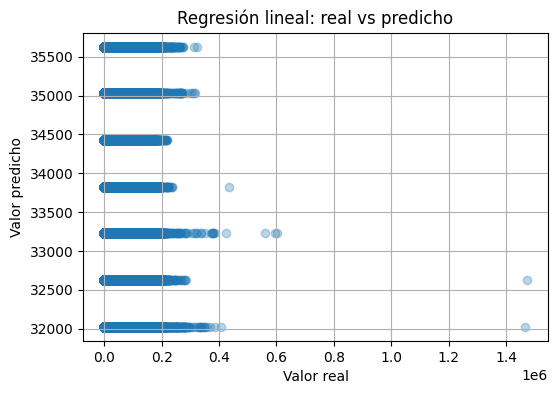

In [ ]:
X_lin = df_clean[["Any"]]
y_lin = df_clean["Valor"]

X_train_lin, X_test_lin, y_train_lin, y_test_lin = train_test_split(
    X_lin, y_lin, test_size=0.2, random_state=42
)

modelo_lin = LinearRegression()
modelo_lin.fit(X_train_lin, y_train_lin)
y_pred_lin = modelo_lin.predict(X_test_lin)

print("Regresión lineal")
print("R2:", round(r2_score(y_test_lin, y_pred_lin), 4))
print("MAE:", round(mean_absolute_error(y_test_lin, y_pred_lin), 4))
print("RMSE:", round(np.sqrt(mean_squared_error(y_test_lin, y_pred_lin)), 4))

plt.figure(figsize=(6,4))
plt.scatter(y_test_lin, y_pred_lin, alpha=0.3)
plt.xlabel("Valor real")
plt.ylabel("Valor predicho")
plt.title("Regresión lineal: real vs predicho")
plt.grid(True)
plt.show()

### Regresión polinómica

In [ ]:
poly = PolynomialFeatures(degree=2, include_bias=False)

X_train_poly = poly.fit_transform(X_train_lin)
X_test_poly = poly.transform(X_test_lin)

modelo_poly = LinearRegression()
modelo_poly.fit(X_train_poly, y_train_lin)
y_pred_poly = modelo_poly.predict(X_test_poly)

print("Regresión polinómica")
print("R2:", round(r2_score(y_test_lin, y_pred_poly), 4))
print("MAE:", round(mean_absolute_error(y_test_lin, y_pred_poly), 4))
print("RMSE:", round(np.sqrt(mean_squared_error(y_test_lin, y_pred_poly)), 4))

Regresión polinómica
R2: 0.0017
MAE: 25766.4791
RMSE: 34361.0198


### Regresión multivariable

In [ ]:
X_multi = df_clean[["Any", "Codi_Postal", "Sector_Economic", "Tram_Horari"]]
y_multi = df_clean["Valor"]

X_multi_encoded = pd.get_dummies(X_multi, drop_first=True)

X_train_multi, X_test_multi, y_train_multi, y_test_multi = train_test_split(
    X_multi_encoded, y_multi, test_size=0.2, random_state=42
)

modelo_multi = LinearRegression()
modelo_multi.fit(X_train_multi, y_train_multi)
y_pred_multi = modelo_multi.predict(X_test_multi)

print("Regresión multivariable")
print("R2:", round(r2_score(y_test_multi, y_pred_multi), 4))
print("MAE:", round(mean_absolute_error(y_test_multi, y_pred_multi), 4))
print("RMSE:", round(np.sqrt(mean_squared_error(y_test_multi, y_pred_multi)), 4))

Regresión multivariable
R2: 0.5554
MAE: 15692.5608
RMSE: 22930.321


### Regresión Logística

In [ ]:
# Variables para clasificación
X_class = df_clean[["Any", "Codi_Postal", "Sector_Economic", "Tram_Horari"]]
y_class = df_clean["consumo_nivel"]

# One-hot encoding
X_class_encoded = pd.get_dummies(X_class, drop_first=True)

# Split estable para todos los clasificadores
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_class_encoded,
    y_class,
    test_size=0.2,
    random_state=42,
    stratify=y_class
)

print("Shapes:")
print("X_train_c:", X_train_c.shape)
print("X_test_c :", X_test_c.shape)
print("y_train_c:", y_train_c.shape)
print("y_test_c :", y_test_c.shape)

Shapes:
X_train_c: (1015056, 47)
X_test_c : (253765, 47)
y_train_c: (1015056,)
y_test_c : (253765,)


In [ ]:
# Implementar regresión logística
scaler_log = StandardScaler()
X_train_log = scaler_log.fit_transform(X_train_c)
X_test_log = scaler_log.transform(X_test_c)

modelo_log = LogisticRegression(max_iter=2000)
modelo_log.fit(X_train_log, y_train_c)
y_pred_log = modelo_log.predict(X_test_log)

print("Regresión logística")
print("Accuracy:", round(accuracy_score(y_test_c, y_pred_log), 4))
print(classification_report(y_test_c, y_pred_log))

Regresión logística
Accuracy: 0.8006
              precision    recall  f1-score   support

        alto       0.77      0.78      0.78     86280
        bajo       0.94      0.86      0.90     83746
       medio       0.71      0.76      0.74     83739

    accuracy                           0.80    253765
   macro avg       0.81      0.80      0.80    253765
weighted avg       0.81      0.80      0.80    253765



## Uso de árboles de decisión

Para detectar las variables más determinantes

Árbol de decisión
Accuracy: 0.7175
              precision    recall  f1-score   support

        alto       0.62      0.74      0.68     86280
        bajo       0.90      0.89      0.90     83746
       medio       0.64      0.51      0.57     83739

    accuracy                           0.72    253765
   macro avg       0.72      0.72      0.71    253765
weighted avg       0.72      0.72      0.71    253765



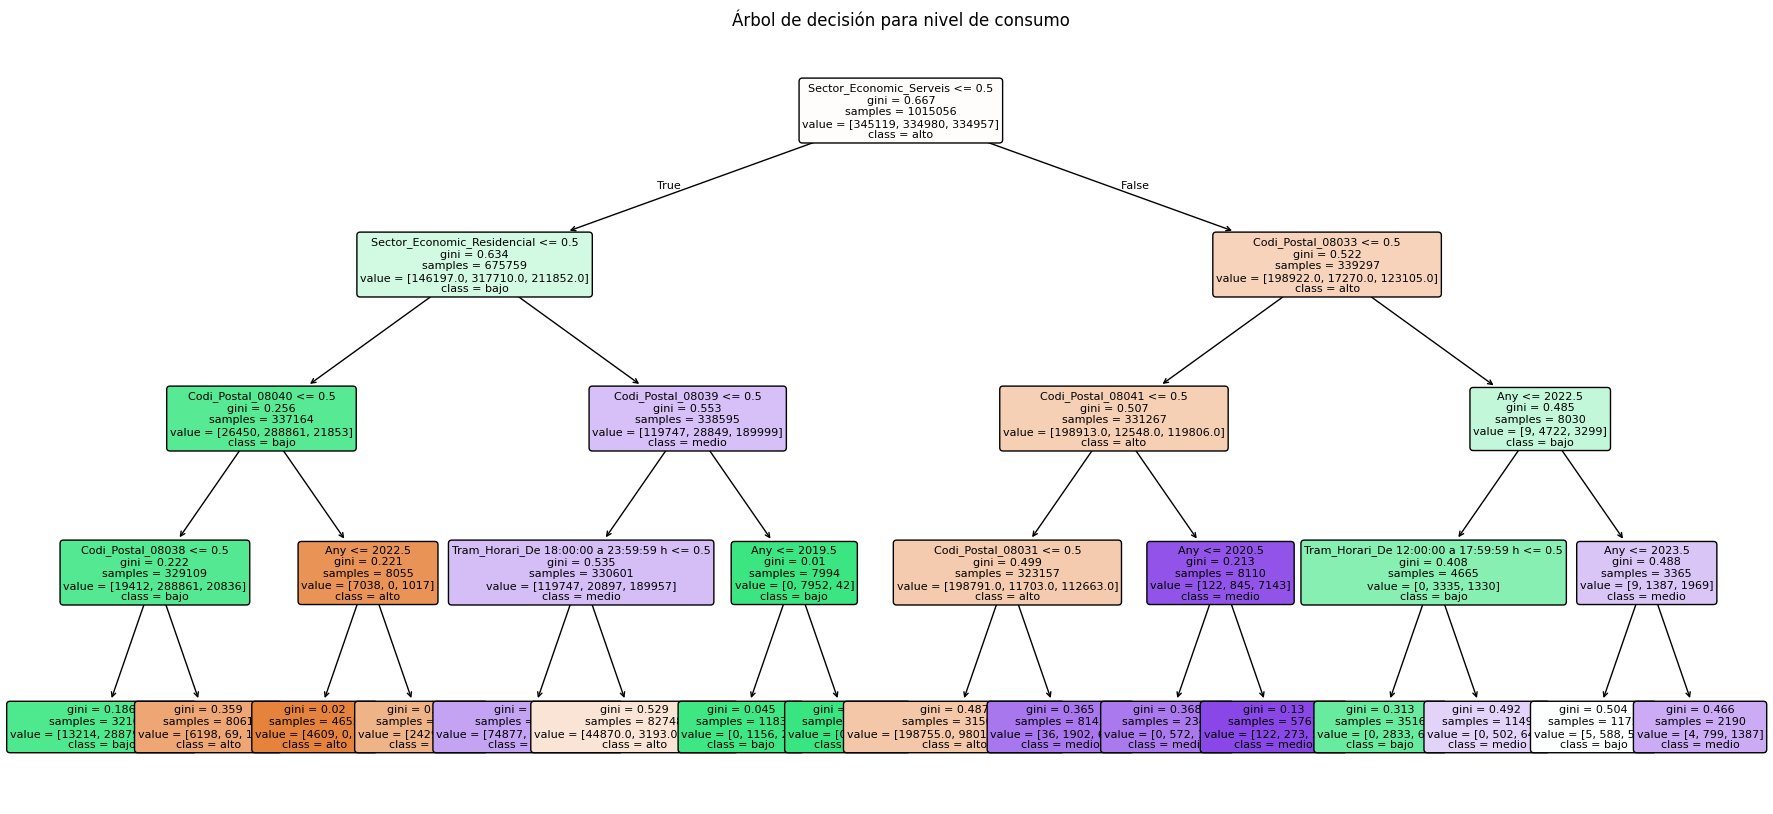

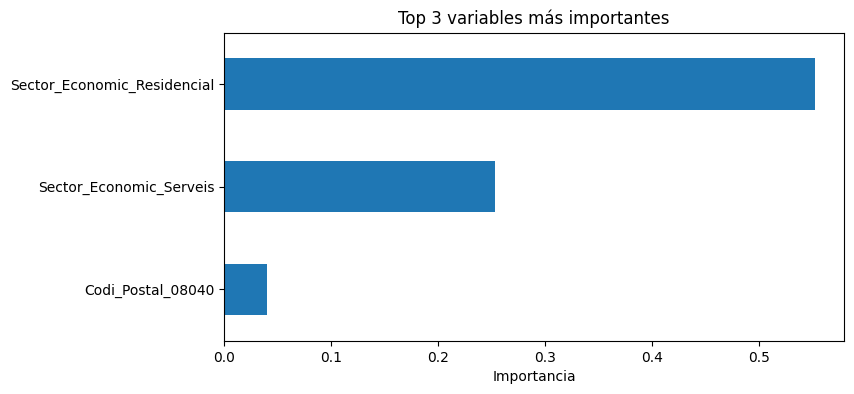

In [ ]:
modelo_tree = DecisionTreeClassifier(max_depth=4, random_state=42)
modelo_tree.fit(X_train_c, y_train_c)
y_pred_tree = modelo_tree.predict(X_test_c)

print("Árbol de decisión")
print("Accuracy:", round(accuracy_score(y_test_c, y_pred_tree), 4))
print(classification_report(y_test_c, y_pred_tree))

plt.figure(figsize=(22,10))
plot_tree(
    modelo_tree,
    feature_names=X_class_encoded.columns,
    class_names=modelo_tree.classes_,
    filled=True,
    rounded=True,
    fontsize=8
)
plt.title("Árbol de decisión para nivel de consumo")
plt.show()

# Variables más importantes
importancias = pd.Series(
    modelo_tree.feature_importances_,
    index=X_class_encoded.columns
).sort_values(ascending=False).head(3)

plt.figure(figsize=(8,4))
importancias.plot(kind="barh")
plt.title("Top 3 variables más importantes")
plt.xlabel("Importancia")
plt.gca().invert_yaxis()
plt.show()

## Algoritmos de clasificación

Para etiquetar los datos en grupos

LogisticRegression: 0.8075
DecisionTree: 0.7403
RandomForest: 0.8789
KNN: 0.8685


,Modelo,Accuracy
2,RandomForest,0.8789
3,KNN,0.8685
0,LogisticRegression,0.8075
1,DecisionTree,0.7403


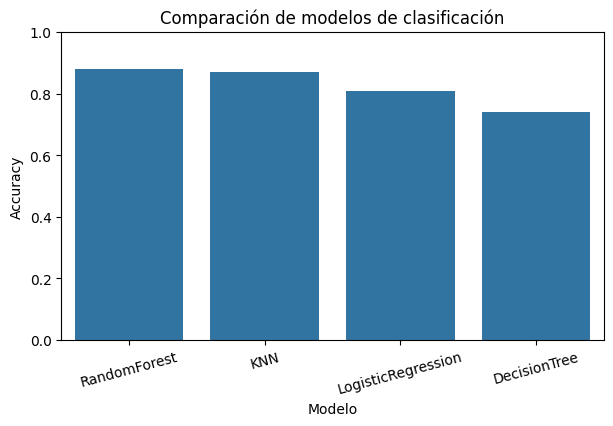

In [ ]:
# Usamos muestra para que KNN no tarde demasiado
df_sample = df_clean.sample(n=50000, random_state=42)

X_sample = pd.get_dummies(df_sample[["Any", "Codi_Postal", "Sector_Economic", "Tram_Horari"]], drop_first=True)
y_sample = df_sample["consumo_nivel"]

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_sample, y_sample, test_size=0.2, random_state=42, stratify=y_sample
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_s)
X_test_scaled = scaler.transform(X_test_s)

modelos = {
    "LogisticRegression": LogisticRegression(max_iter=2000),
    "DecisionTree": DecisionTreeClassifier(max_depth=5, random_state=42),
    "RandomForest": RandomForestClassifier(n_estimators=100, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5)
}

resultados = []
for nombre, modelo in modelos.items():
    if nombre in ["LogisticRegression", "KNN"]:
        modelo.fit(X_train_scaled, y_train_s)
        pred = modelo.predict(X_test_scaled)
    else:
        modelo.fit(X_train_s, y_train_s)
        pred = modelo.predict(X_test_s)
    acc = accuracy_score(y_test_s, pred)
    resultados.append([nombre, acc])
    print(f"{nombre}: {round(acc, 4)}")

resultados_df = pd.DataFrame(resultados, columns=["Modelo", "Accuracy"]).sort_values(by="Accuracy", ascending=False)
display(resultados_df)

plt.figure(figsize=(7, 4))
sns.barplot(data=resultados_df, x="Modelo", y="Accuracy")
plt.title("Comparación de modelos de clasificación")
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.show()

## Gráficos

Para ilustrar las hipótesis

### Heatmap sector x tramo

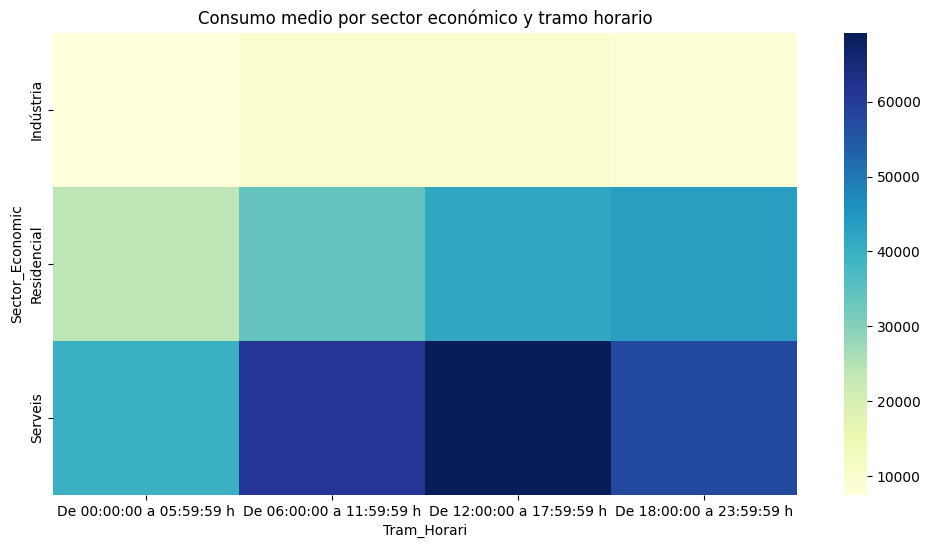

In [ ]:
tabla_sector_tramo = df_clean.pivot_table(
    values="Valor",
    index="Sector_Economic",
    columns="Tram_Horari",
    aggfunc="mean"
)

plt.figure(figsize=(12,6))
sns.heatmap(tabla_sector_tramo, cmap="YlGnBu")
plt.title("Consumo medio por sector económico y tramo horario")
plt.show()

### Evolución anual por sector principal

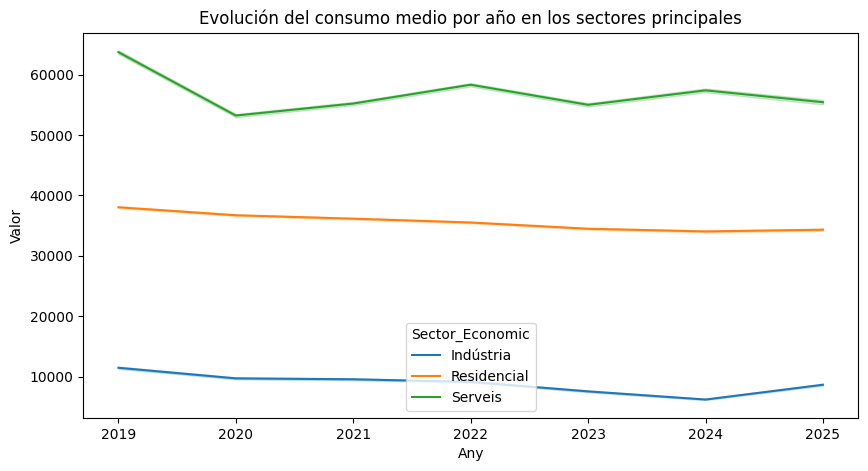

In [ ]:
top_sectores = df_clean.groupby("Sector_Economic")["Valor"].sum().sort_values(ascending=False).head(5).index
df_top = df_clean[df_clean["Sector_Economic"].isin(top_sectores)]

plt.figure(figsize=(10,5))
sns.lineplot(data=df_top, x="Any", y="Valor", hue="Sector_Economic", estimator="mean")
plt.title("Evolución del consumo medio por año en los sectores principales")
plt.show()

### consumo medio por código postal y sector económico

<Figure size 1400x600 with 0 Axes>

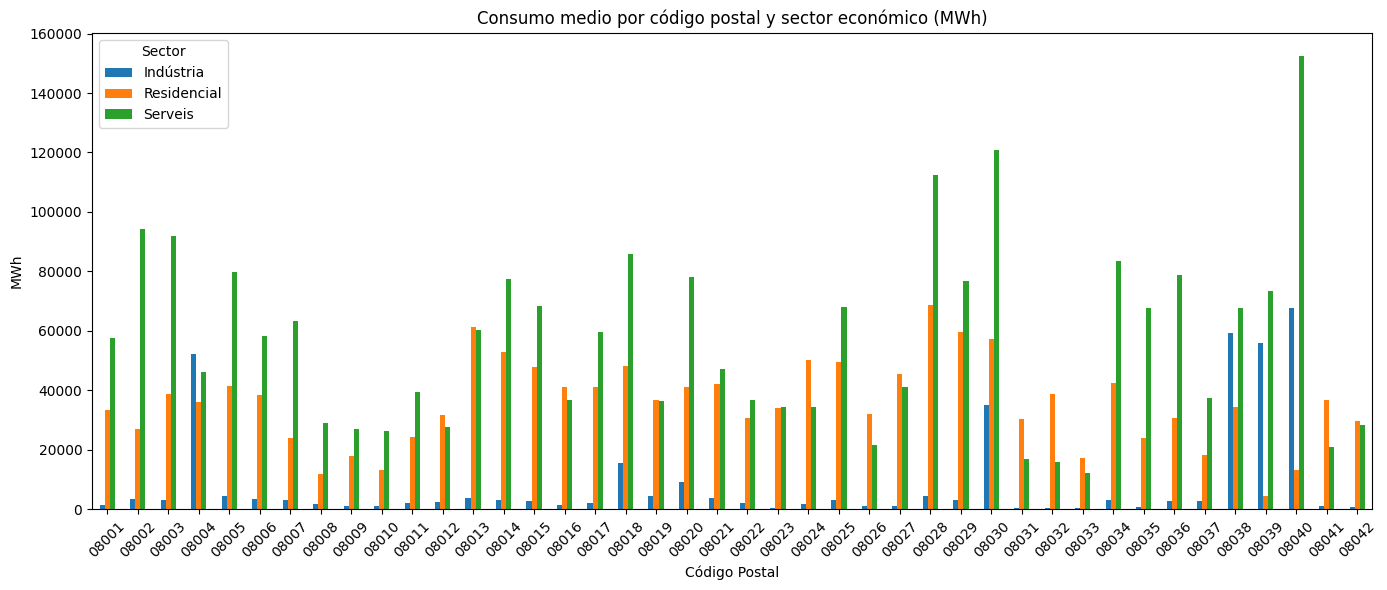

In [ ]:
consumo_cp_sector = df_clean.groupby(["Codi_Postal", "Sector_Economic"])["Valor"].mean().unstack()

plt.figure(figsize=(14, 6))
consumo_cp_sector.plot(kind="bar", figsize=(14, 6))
plt.title("Consumo medio por código postal y sector económico (MWh)")
plt.xlabel("Código Postal")
plt.ylabel("MWh")
plt.legend(title="Sector")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Uso de API y clustering

### Uso de API

Para consultar metadatos del dataset.

In [ ]:
import requests

url_api = "https://opendata-ajuntament.barcelona.cat/data/api/3/action/package_show?id=consum-electricitat-bcn"
resp = requests.get(url_api, timeout=20)
data_api = resp.json()

print("Título del dataset:")
print(data_api["result"]["title"])
print("\nDescripción:")
print(data_api["result"]["notes"][:500])
print("\nNúmero de recursos (archivos):")
print(len(data_api["result"]["resources"]))
print("\nArchivos disponibles:")
for r in data_api["result"]["resources"]:
    print(f"  - {r['name']} ({r['format']})")

Título del dataset:
Electricity consumption by postal code, economic sector and time interval in teh city of Barcelona

Descripción:
Daily electric cosumption by postal code, economic sector and time interval in the city of Barcelona, according to the data provided by the  __[Datadis](https://datadis.es)__ platform.  

 

Número de recursos (archivos):
7

Archivos disponibles:
  - 2025_consum_electricitat_BCN.csv (CSV)
  - 2024_consum_electricitat_bcn.csv (CSV)
  - 2023_consum_electricitat_bcn.csv (CSV)
  - 2022_consum_electricitat_bcn.csv (CSV)
  - 2021_consum_electricitat_bcn.csv (CSV)
  - 2020_consum_electricitat_bcn.csv (CSV)
  - 2019_consum_electricitat_bcn.csv (CSV)


### Clustering

Para agrupar códigos postales con patrones de consumo similares.

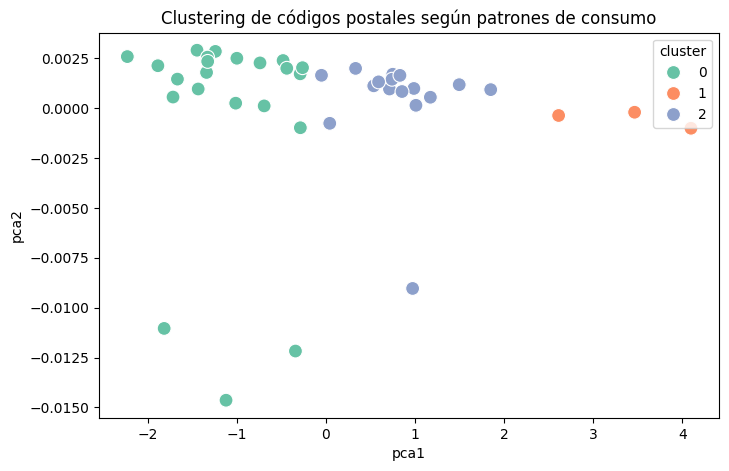

,Codi_Postal,consumo_total,consumo_medio,diversidad_sector,diversidad_tramo,años_disponibles,cluster,pca1,pca2
0,08001,930311385,30745.964208,3,4,7,0,-0.286991,0.001727
1,08002,1255996515,41505.453058,3,4,7,2,0.714991,0.000966
2,08003,1352190398,44696.076356,3,4,7,2,1.011528,0.000149
3,08004,1352396119,44702.876376,3,4,7,2,1.012161,0.000148
4,08005,1268226680,41892.996399,3,4,7,2,0.751849,0.001706


In [ ]:
cp_agg = df_clean.groupby("Codi_Postal").agg(
    consumo_total=("Valor", "sum"),
    consumo_medio=("Valor", "mean"),
    diversidad_sector=("Sector_Economic", "nunique"),
    diversidad_tramo=("Tram_Horari", "nunique"),
    años_disponibles=("Any", "nunique")
).reset_index()

X_cluster = cp_agg.drop(columns=["Codi_Postal"])

scaler_cluster = StandardScaler()
X_cluster_scaled = scaler_cluster.fit_transform(X_cluster)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
cp_agg["cluster"] = kmeans.fit_predict(X_cluster_scaled)

pca = PCA(n_components=2)
coords = pca.fit_transform(X_cluster_scaled)

cp_agg["pca1"] = coords[:,0]
cp_agg["pca2"] = coords[:,1]

plt.figure(figsize=(8,5))
sns.scatterplot(data=cp_agg, x="pca1", y="pca2", hue="cluster", palette="Set2", s=100)
plt.title("Clustering de códigos postales según patrones de consumo")
plt.show()

display(cp_agg.head())

### Mapa geoespacial de consumo por código postal

In [ ]:
# Obtener coordenadas reales de cada código postal via Nominatim (OpenStreetMap)
import requests
import time

codigos_postales = sorted(df_clean['Codi_Postal'].unique())
coordenadas = {}

for cp in codigos_postales:
    url = f"https://nominatim.openstreetmap.org/search?postalcode={cp}&country=Spain&format=json&limit=1"
    resp = requests.get(url, headers={"User-Agent": "colab-project"})
    datos = resp.json()
    if datos:
        coordenadas[cp] = [float(datos[0]['lat']), float(datos[0]['lon'])]
        print(f"0{cp}: {coordenadas[cp]}")
    else:
        print(f"0{cp}: no encontrado")
    time.sleep(1)  # respetar límite de la API

print("\nTotal coordenadas obtenidas:", len(coordenadas))

008001: [41.3802394, 2.169317]
008002: [41.3819939, 2.1765432]
008003: [41.3858957, 2.180401]
008004: [41.3729298, 2.1621892]
008005: [41.3996634, 2.2010414]
008006: [41.4005748, 2.1499914]
008007: [41.3902834, 2.1654065]
008008: [41.3965123, 2.1621513]
008009: [41.394723, 2.1692685]
008010: [41.3915202, 2.1745968]
008011: [41.3848023, 2.1590351]
008012: [41.4022171, 2.1573815]
008013: [41.4001822, 2.1775812]
008014: [41.3737424, 2.1386277]
008015: [41.3778415, 2.1570387]
008016: [41.4337493, 2.1794709]
008017: [41.406928, 2.1136977]
008018: [41.4031873, 2.1916208]
008019: [41.4108662, 2.2118218]
008020: [41.4205438, 2.2015445]
008021: [41.396274, 2.1412773]
008022: [41.4053425, 2.1351549]
008023: [41.4130025, 2.1463562]
008024: [41.4107986, 2.1601333]
008025: [41.4087391, 2.170764]
008026: [41.4117957, 2.1855148]
008027: [41.4214851, 2.185959]
008028: [41.3782975, 2.1280546]
008029: [41.3864789, 2.1459477]
008030: [41.4349149, 2.1916648]
008031: [41.4318442, 2.1641261]
008032: [41.423

In [ ]:
# Mapa geoespacial de consumo por código postal
!pip install folium -q

import folium

# Consumo total por código postal
consumo_cp = df_clean.groupby("Codi_Postal")["Valor"].sum().reset_index()
consumo_cp.columns = ["Codi_Postal", "Consumo_Total"]

consumo_max = consumo_cp["Consumo_Total"].max()

mapa = folium.Map(location=[41.3900, 2.1540], zoom_start=12)

for _, row in consumo_cp.iterrows():
    cp = row["Codi_Postal"]
    consumo = row["Consumo_Total"]
    if cp in coordenadas:
        lat, lon = coordenadas[cp]
        intensidad = consumo / consumo_max
        color = f"#{int(255 * intensidad):02x}{int(255 * (1 - intensidad)):02x}00"
        folium.CircleMarker(
            location=[lat, lon],
            radius=15,
            color=color,
            fill=True,
            fill_color=color,
            fill_opacity=0.7,
            popup=f"CP: {cp} | Consumo: {int(consumo):,} MWh"
        ).add_to(mapa)

mapa.save("mapa_consumo_barcelona.html")
print("Mapa guardado como mapa_consumo_barcelona.html")
display(mapa)

Mapa guardado como mapa_consumo_barcelona.html


## Reflexión final y propuesta social

A partir del análisis realizado, se ha podido comprobar que el consumo eléctrico en Barcelona depende claramente del código postal, del sector económico y de la franja horaria, y que no se distribuye de forma equilibrada en la ciudad.

Los resultados obtenidos indican que determinadas zonas y sectores concentran una parte significativamente mayor del consumo. El sector de `servicios` es el mayor consumidor, por encima del sector `residencial`, y zonas como la Zona Franca (08040) o Sant Andreu (08030) destacan considerablemente sobre el resto. Estos patrones pueden contribuir a orientar de forma más eficiente las políticas de eficiencia energética.

Estos datos resultan especialmente relevantes para comprender que el elevado consumo en zonas como la Zona Franca y Sant Andreu no es casual. En la Zona Franca se concentra una intensa actividad económica, con un polígono que reúne 317 empresas en 4,7 millones de m², mientras que en Sant Andreu se encuentran grandes superficies comerciales como La Maquinista. La presencia de infraestructuras de esta envergadura tiene un impacto directo y significativo en la demanda energética de estas zonas.

Como propuesta de mejora, se plantea la aplicación de las siguientes medidas:

* Ampliación de la generación solar mediante la instalación de placas solares en cubiertas y techos de grandes superficies.
* Sustitución de la iluminación convencional por tecnología LED en zonas comunes y comerciales.
* Optimización de la climatización en la franja de mayor consumo, especialmente entre las 12:00 y las 18:00.
* Reducción de consumos no esenciales, como por ejemplo:
    1. Regulación de la iluminación en pasillos, aparcamientos y zonas de escaso tránsito mediante sensores.
    2. Reducción de la iluminación decorativa y de zonas secundarias.

En conclusión, el presente proyecto demuestra que los datos abiertos constituyen una herramienta de gran valor para comprender la realidad urbana y fundamentar decisiones con impacto social y ambiental.